# Amazon-Style E-Commerce Sales Analytics

## 06 — Discount & Pricing Analysis

### Objective

The objective of this notebook is to analyze discounting and pricing behavior across products, categories, brands, and customer transactions.

The analysis focuses on:

- Discount distribution
- Gross product value before discount
- Discount amount
- Net product sales value after discount
- Effective selling price
- Discount levels by category and brand
- Discount versus quantity sold
- Discount versus order value
- High-discount products
- Pricing differences across categories
- Business implications of the observed discount patterns

### Important Limitation

The dataset does not contain product cost or profit information.

Therefore, this notebook **does not calculate profit, profit margin, or true discount profitability**.

A higher discount may be associated with higher sales volume, but this analysis cannot establish that the discount caused the higher volume.

Also, `TotalAmount` includes the discounted product amount plus tax and shipping cost. Therefore, product-level pricing calculations are kept separate from total order value where appropriate.


### Key Business Questions

1. What is the overall discount level in the dataset?
2. How much product value is given up through discounts?
3. Which discount levels are most frequently used?
4. Which categories receive the highest average discounts?
5. Which brands receive the highest average discounts?
6. Does higher discounting coincide with higher quantity sold?
7. Does higher discounting coincide with higher order value?
8. Which products receive the highest discounts?
9. Which categories have the highest effective selling prices?
10. How does discounting affect the relationship between list price and selling price?
11. Which discount levels contribute the most sales value?
12. What pricing and discount patterns should be considered for business decisions?


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Load the cleaned dataset

file_path = "C:/Users/Hp/OneDrive/Desktop/Projects/Amazon E-Commerce Sales Performance & Customer Analytics/Data/Amazon_Cleaned.csv"

df = pd.read_csv(file_path)

df["OrderDate"] = pd.to_datetime(df["OrderDate"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (100000, 25)


In [3]:
# Confirm the fields required for discount and pricing analysis

required_columns = [
    "OrderID",
    "ProductID",
    "ProductName",
    "Category",
    "Brand",
    "Quantity",
    "UnitPrice",
    "Discount",
    "Tax",
    "ShippingCost",
    "TotalAmount"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are available.")


All required columns are available.


## 1. Pricing & Discount Metric Definitions

To keep the analysis consistent with the previous sales-performance notebook, the following measures are used.

- **Gross Product Value:** `Quantity × UnitPrice`
- **Discount Amount:** `Quantity × UnitPrice × Discount`
- **Net Product Sales:** `Gross Product Value − Discount Amount`
- **Effective Unit Price:** `UnitPrice × (1 − Discount)`
- **Total Order Value:** `TotalAmount`
- **Weighted Discount Rate:** Total discount amount divided by gross product value

The weighted discount rate is preferred for overall discount measurement because it accounts for transaction value rather than giving every order equal weight.


In [4]:
# Create pricing and discount metrics

df["GrossProductValue"] = (
    df["Quantity"] * df["UnitPrice"]
)

df["DiscountAmount"] = (
    df["GrossProductValue"] * df["Discount"]
)

df["NetProductSales"] = (
    df["GrossProductValue"] - df["DiscountAmount"]
)

df["EffectiveUnitPrice"] = (
    df["UnitPrice"] * (1 - df["Discount"])
)

df["DiscountPercent"] = (
    df["Discount"] * 100
)

df[
    [
        "Quantity",
        "UnitPrice",
        "Discount",
        "GrossProductValue",
        "DiscountAmount",
        "NetProductSales",
        "EffectiveUnitPrice",
        "TotalAmount"
    ]
].head()


,Quantity,UnitPrice,Discount,GrossProductValue,DiscountAmount,NetProductSales,EffectiveUnitPrice,TotalAmount
0,3,106.59,0.00,319.77,0.0000,319.7700,106.5900,319.86
1,1,251.37,0.05,251.37,12.5685,238.8015,238.8015,259.64
2,3,35.03,0.10,105.09,10.5090,94.5810,31.5270,108.06
3,5,33.58,0.15,167.90,25.1850,142.7150,28.5430,159.66
4,2,515.64,0.25,1031.28,257.8200,773.4600,386.7300,821.36


## 2. Overall Discount & Pricing Overview

This section establishes the overall scale of product pricing and discounting before moving to category, brand, and product-level analysis.


In [5]:
total_gross_product_value = df["GrossProductValue"].sum()
total_discount_amount = df["DiscountAmount"].sum()
total_net_product_sales = df["NetProductSales"].sum()
total_order_value = df["TotalAmount"].sum()

weighted_discount_rate = (
    total_discount_amount / total_gross_product_value * 100
)

average_discount_rate = df["Discount"].mean() * 100
median_discount_rate = df["Discount"].median() * 100
average_unit_price = df["UnitPrice"].mean()
average_effective_unit_price = df["EffectiveUnitPrice"].mean()

discount_overview = pd.DataFrame({
    "Metric": [
        "Total Gross Product Value",
        "Total Discount Amount",
        "Total Net Product Sales",
        "Total Order Value",
        "Weighted Discount Rate",
        "Average Discount Rate",
        "Median Discount Rate",
        "Average Unit Price",
        "Average Effective Unit Price"
    ],
    "Value": [
        total_gross_product_value,
        total_discount_amount,
        total_net_product_sales,
        total_order_value,
        weighted_discount_rate,
        average_discount_rate,
        median_discount_rate,
        average_unit_price,
        average_effective_unit_price
    ]
})

discount_overview


,Metric,Value
0,Total Gross Product Value,9.102121e+07
1,Total Discount Amount,6.783119e+06
2,Total Net Product Sales,8.423809e+07
3,Total Order Value,9.182565e+07
4,Weighted Discount Rate,7.452240e+00
5,Average Discount Rate,7.422600e+00
6,Median Discount Rate,5.000000e+00
7,Average Unit Price,3.029057e+02
8,Average Effective Unit Price,2.803349e+02


In [6]:
print(f"Gross Product Value       : ${total_gross_product_value:,.2f}")
print(f"Discount Amount           : ${total_discount_amount:,.2f}")
print(f"Net Product Sales         : ${total_net_product_sales:,.2f}")
print(f"Total Order Value         : ${total_order_value:,.2f}")
print(f"Weighted Discount Rate    : {weighted_discount_rate:.2f}%")
print(f"Average Discount Rate     : {average_discount_rate:.2f}%")
print(f"Median Discount Rate      : {median_discount_rate:.2f}%")
print(f"Average Unit Price        : ${average_unit_price:,.2f}")
print(f"Average Effective Price   : ${average_effective_unit_price:,.2f}")


Gross Product Value       : $91,021,212.99
Discount Amount           : $6,783,119.19
Net Product Sales         : $84,238,093.80
Total Order Value         : $91,825,647.92
Weighted Discount Rate    : 7.45%
Average Discount Rate     : 7.42%
Median Discount Rate      : 5.00%
Average Unit Price        : $302.91
Average Effective Price   : $280.33


## 3. Discount Distribution

The dataset uses discrete discount levels. The frequency of each level is analyzed to understand the pricing policy represented in the transactions.


In [7]:
discount_distribution = (
    df.groupby("DiscountPercent")
      .agg(
          Orders=("OrderID", "nunique"),
          GrossProductValue=("GrossProductValue", "sum"),
          DiscountAmount=("DiscountAmount", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          Units=("Quantity", "sum")
      )
      .reset_index()
      .sort_values("DiscountPercent")
)

discount_distribution["Order_Share_%"] = (
    discount_distribution["Orders"]
    / discount_distribution["Orders"].sum()
    * 100
)

discount_distribution["Sales_Share_%"] = (
    discount_distribution["NetProductSales"]
    / discount_distribution["NetProductSales"].sum()
    * 100
)

discount_distribution


,DiscountPercent,Orders,GrossProductValue,DiscountAmount,NetProductSales,Units,Order_Share_%,Sales_Share_%
0,0.0,40246,36514370.18,0.000000e+00,3.651437e+07,120977,40.246,43.346624
1,5.0,19889,18104849.73,9.052425e+05,1.719961e+07,59570,19.889,20.417850
2,10.0,14910,13632554.96,1.363255e+06,1.226930e+07,44711,14.910,14.565025
3,15.0,10041,9111945.12,1.366792e+06,7.745153e+06,30114,10.041,9.194360
4,20.0,7939,7221081.14,1.444216e+06,5.776865e+06,23766,7.939,6.857782
5,25.0,4986,4546207.00,1.136552e+06,3.409655e+06,14939,4.986,4.047641
6,30.0,1989,1890204.86,5.670615e+05,1.323143e+06,6063,1.989,1.570719


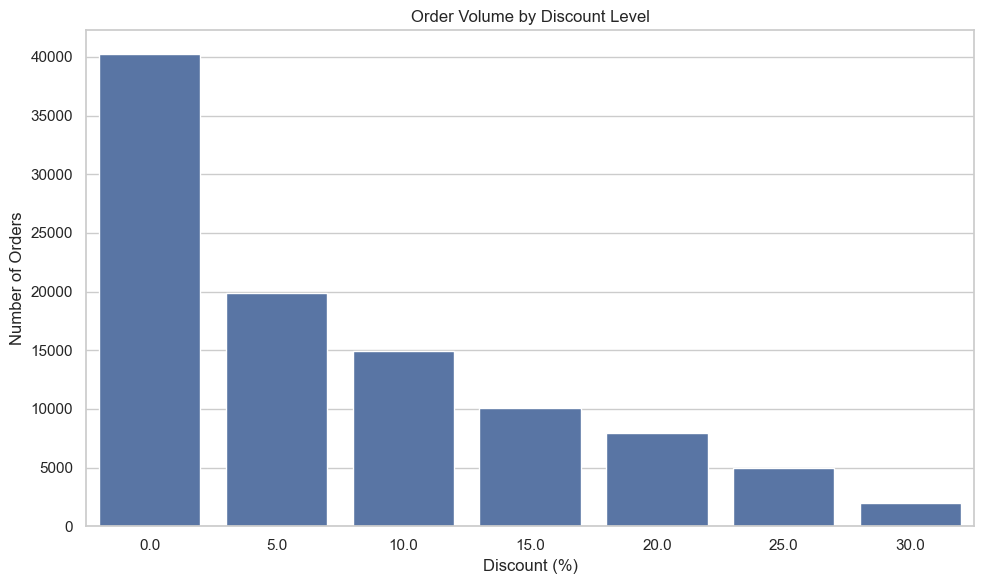

In [8]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=discount_distribution,
    x="DiscountPercent",
    y="Orders"
)

plt.title("Order Volume by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


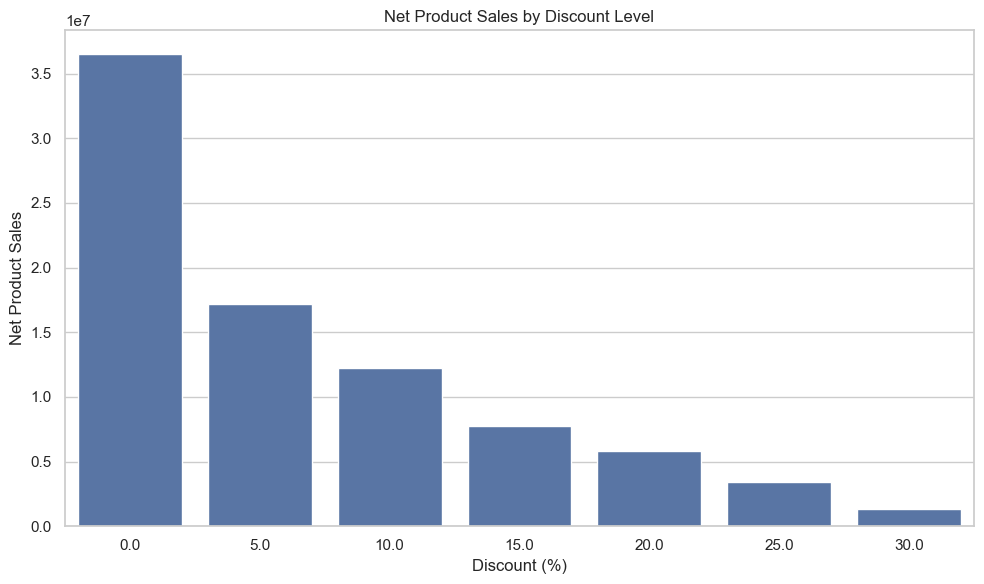

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=discount_distribution,
    x="DiscountPercent",
    y="NetProductSales"
)

plt.title("Net Product Sales by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Net Product Sales")

plt.tight_layout()
plt.show()


### Interpretation

The distribution shows which discount levels are used most frequently and which levels contribute the greatest amount of product sales.

Frequency and sales contribution should be considered separately. A discount level can be common because it is applied to many lower-value transactions, while another discount level can contribute substantial sales through fewer high-value transactions.


## 4. Discount Amount & Price Reduction Analysis

This section quantifies the monetary value of discounts and the difference between the original unit price and the effective selling price.


In [10]:
price_reduction = pd.DataFrame({
    "Metric": [
        "Average List Unit Price",
        "Average Effective Unit Price",
        "Average Unit Price Reduction",
        "Total Discount Amount",
        "Discount Amount per Order"
    ],
    "Value": [
        df["UnitPrice"].mean(),
        df["EffectiveUnitPrice"].mean(),
        (df["UnitPrice"] - df["EffectiveUnitPrice"]).mean(),
        df["DiscountAmount"].sum(),
        df["DiscountAmount"].mean()
    ]
})

price_reduction


,Metric,Value
0,Average List Unit Price,3.029057e+02
1,Average Effective Unit Price,2.803349e+02
2,Average Unit Price Reduction,2.257089e+01
3,Total Discount Amount,6.783119e+06
4,Discount Amount per Order,6.783119e+01


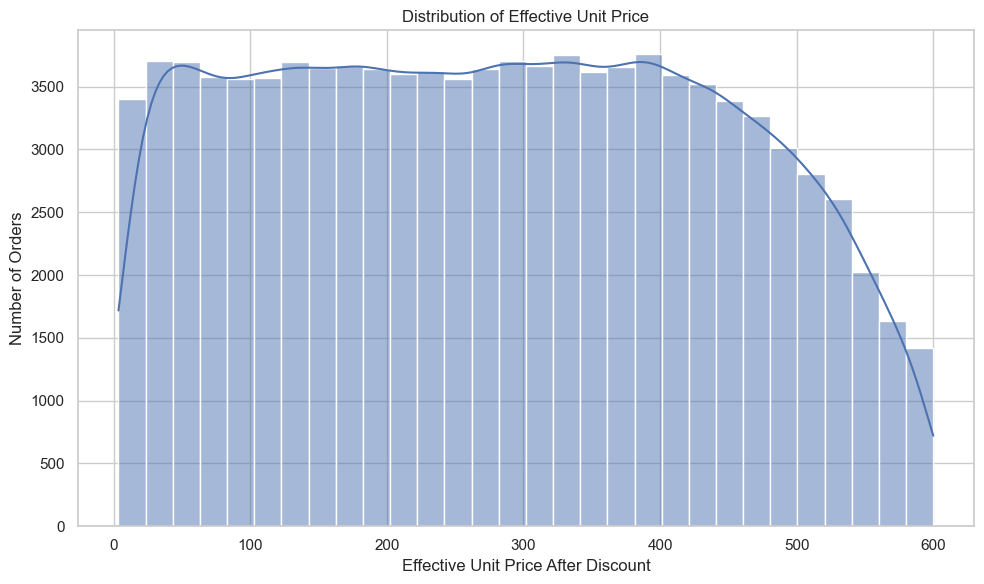

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="EffectiveUnitPrice",
    bins=30,
    kde=True
)

plt.title("Distribution of Effective Unit Price")
plt.xlabel("Effective Unit Price After Discount")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


## 5. Discount Performance by Category

Category-level analysis identifies where discounting is most aggressive and whether highly discounted categories also generate substantial sales volume.


In [12]:
category_discount = (
    df.groupby("Category")
      .agg(
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum"),
          GrossProductValue=("GrossProductValue", "sum"),
          DiscountAmount=("DiscountAmount", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          Average_Discount=("Discount", "mean"),
          Median_Discount=("Discount", "median"),
          Average_Unit_Price=("UnitPrice", "mean"),
          Average_Effective_Price=("EffectiveUnitPrice", "mean")
      )
      .reset_index()
)

category_discount["Weighted_Discount_%"] = (
    category_discount["DiscountAmount"]
    / category_discount["GrossProductValue"]
    * 100
)

category_discount["Sales_Share_%"] = (
    category_discount["NetProductSales"]
    / category_discount["NetProductSales"].sum()
    * 100
)

category_discount = category_discount.sort_values(
    "NetProductSales",
    ascending=False
)

category_discount


,Category,Orders,Units,GrossProductValue,DiscountAmount,NetProductSales,Average_Discount,Median_Discount,Average_Unit_Price,Average_Effective_Price,Weighted_Discount_%,Sales_Share_%
2,Electronics,16853,50696,15432682.26,1.144068e+06,1.428861e+07,0.074340,0.05,302.926827,280.417528,7.413281,16.962177
4,Sports & Outdoors,16804,50543,15214315.21,1.132323e+06,1.408199e+07,0.074000,0.05,301.757574,279.317202,7.442487,16.716893
1,Clothing,16439,49523,15126422.24,1.127570e+06,1.399885e+07,0.073970,0.05,305.196414,282.381379,7.454306,16.618197
0,Books,16752,49981,15129134.02,1.132719e+06,1.399641e+07,0.073896,0.05,302.023176,279.554902,7.487008,16.615303
5,Toys & Games,16542,49773,15087879.05,1.117829e+06,1.397005e+07,0.074066,0.05,302.810143,280.352128,7.408791,16.584005
3,Home & Kitchen,16610,49624,15030780.21,1.128609e+06,1.390217e+07,0.075084,0.05,302.764196,280.024488,7.508652,16.503426


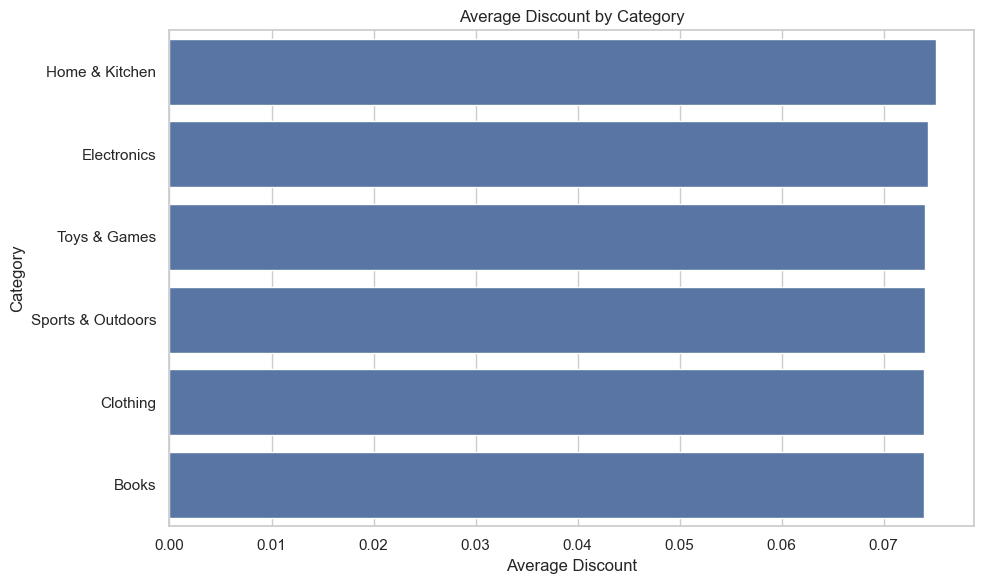

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_discount.sort_values(
        "Average_Discount",
        ascending=False
    ),
    x="Average_Discount",
    y="Category"
)

plt.title("Average Discount by Category")
plt.xlabel("Average Discount")
plt.ylabel("Category")

plt.tight_layout()
plt.show()


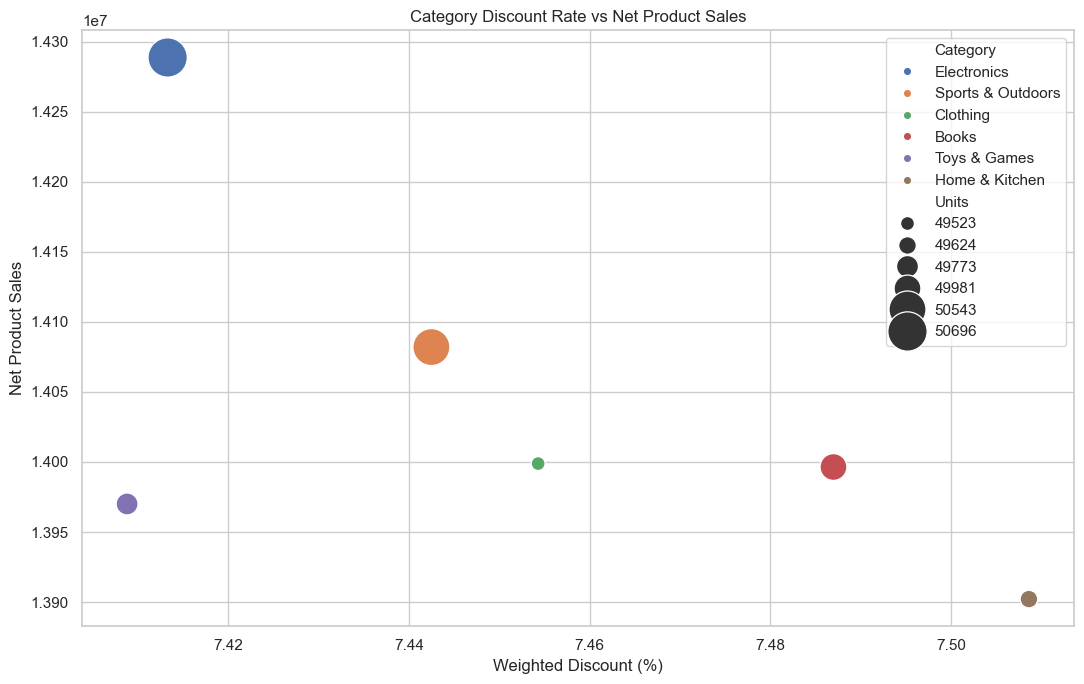

In [14]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=category_discount,
    x="Weighted_Discount_%",
    y="NetProductSales",
    size="Units",
    hue="Category",
    sizes=(100, 800)
)

plt.title("Category Discount Rate vs Net Product Sales")
plt.xlabel("Weighted Discount (%)")
plt.ylabel("Net Product Sales")

plt.tight_layout()
plt.show()


## 6. Discount Performance by Brand

Brand-level discount analysis highlights brands that rely more heavily on discounting and compares this with their sales contribution.


In [15]:
brand_discount = (
    df.groupby("Brand")
      .agg(
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum"),
          GrossProductValue=("GrossProductValue", "sum"),
          DiscountAmount=("DiscountAmount", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          Average_Discount=("Discount", "mean"),
          Average_Unit_Price=("UnitPrice", "mean"),
          Average_Effective_Price=("EffectiveUnitPrice", "mean")
      )
      .reset_index()
)

brand_discount["Weighted_Discount_%"] = (
    brand_discount["DiscountAmount"]
    / brand_discount["GrossProductValue"]
    * 100
)

brand_discount["Sales_Share_%"] = (
    brand_discount["NetProductSales"]
    / brand_discount["NetProductSales"].sum()
    * 100
)

brand_discount = brand_discount.sort_values(
    "NetProductSales",
    ascending=False
)

brand_discount.head(15)


,Brand,Orders,Units,GrossProductValue,DiscountAmount,NetProductSales,Average_Discount,Average_Unit_Price,Average_Effective_Price,Weighted_Discount_%,Sales_Share_%
2,CoreTech,10127,30430,9248868.28,678269.4445,8.570599e+06,0.073413,302.659402,280.428631,7.333540,10.174255
5,KiddoFun,10077,30168,9241861.98,685496.1460,8.556366e+06,0.074253,302.933459,280.385514,7.417295,10.157359
7,ReadMore,10204,30421,9189325.71,675022.8430,8.514303e+06,0.073182,301.699130,279.410202,7.345728,10.107426
8,UrbanStyle,9854,30104,9189994.88,696623.0305,8.493372e+06,0.075223,304.784602,281.692992,7.580233,10.082578
9,Zenith,9990,30058,9158670.71,690533.2275,8.468137e+06,0.073158,304.996644,282.136847,7.539667,10.052622
0,Apex,9937,29955,9058660.73,672478.7310,8.386182e+06,0.074479,302.643907,280.208052,7.423600,9.955332
6,NexPro,9962,29791,9007085.24,668631.4335,8.338454e+06,0.074498,302.164584,279.787341,7.423394,9.898673
3,FitLife,10147,30121,8999052.58,688728.3320,8.310324e+06,0.075791,299.429233,276.508492,7.653343,9.865281
1,BrightLux,9907,29616,8976825.89,673562.5865,8.303263e+06,0.074533,303.494065,280.888129,7.503349,9.856898
4,HomeEase,9795,29476,8950866.99,653773.4120,8.297094e+06,0.073747,304.392091,282.034644,7.304023,9.849574


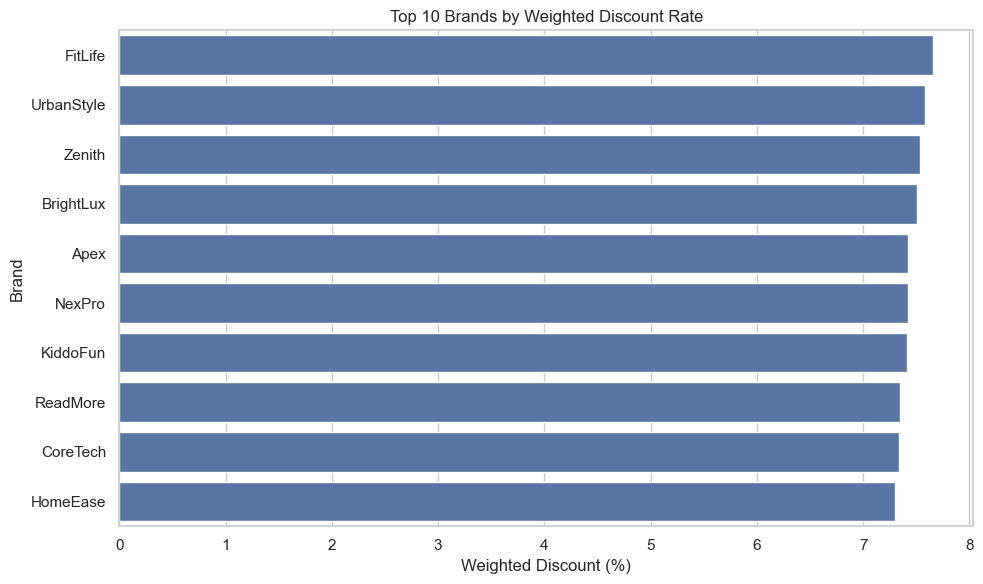

In [16]:
top_discounted_brands = (
    brand_discount
    .sort_values("Weighted_Discount_%", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_discounted_brands,
    x="Weighted_Discount_%",
    y="Brand"
)

plt.title("Top 10 Brands by Weighted Discount Rate")
plt.xlabel("Weighted Discount (%)")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()


## 7. Discount vs Quantity Sold

The relationship between discount level and quantity is examined to determine whether higher discount transactions tend to contain more units.

This is an **association analysis**, not a causal test.


In [17]:
discount_quantity = (
    df.groupby("DiscountPercent")
      .agg(
          Average_Quantity=("Quantity", "mean"),
          Median_Quantity=("Quantity", "median"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum")
      )
      .reset_index()
)

discount_quantity


,DiscountPercent,Average_Quantity,Median_Quantity,Orders,Units,NetProductSales
0,0.0,3.005938,3.0,40246,120977,3.651437e+07
1,5.0,2.995123,3.0,19889,59570,1.719961e+07
2,10.0,2.998726,3.0,14910,44711,1.226930e+07
3,15.0,2.999104,3.0,10041,30114,7.745153e+06
4,20.0,2.993576,3.0,7939,23766,5.776865e+06
5,25.0,2.996189,3.0,4986,14939,3.409655e+06
6,30.0,3.048265,3.0,1989,6063,1.323143e+06


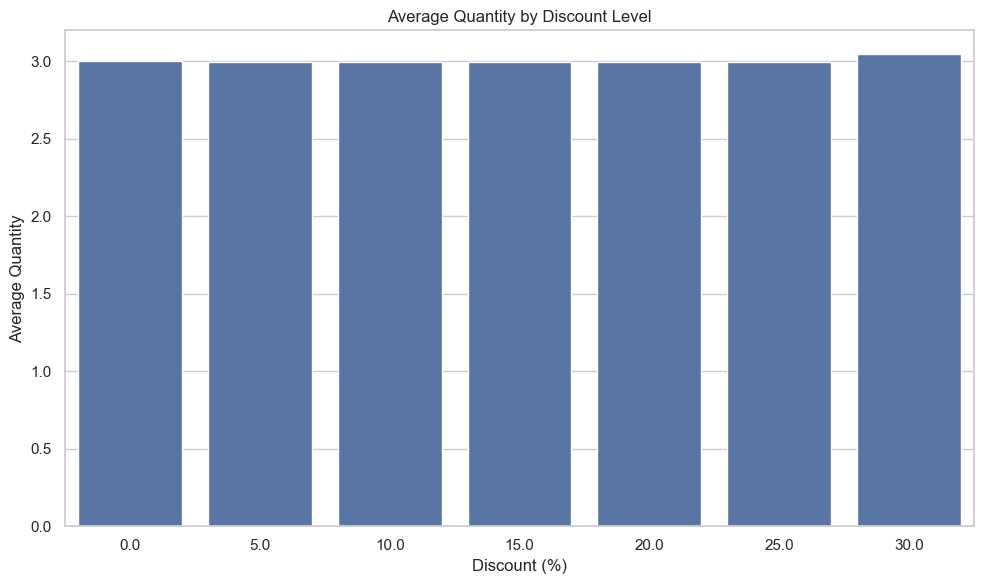

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=discount_quantity,
    x="DiscountPercent",
    y="Average_Quantity"
)

plt.title("Average Quantity by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Average Quantity")

plt.tight_layout()
plt.show()


In [19]:
discount_quantity_correlation = (
    discount_quantity[
        ["DiscountPercent", "Average_Quantity"]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Correlation between discount level and average quantity: "
    f"{discount_quantity_correlation:.3f}"
)


Correlation between discount level and average quantity: 0.494


## 8. Discount vs Order Value

The relationship between discount and total order value is analyzed using a sample for visualization when necessary.

Because `TotalAmount` includes product value, tax, and shipping, this chart should be interpreted as an association between discount level and total recorded order value rather than a direct measure of discount profitability.


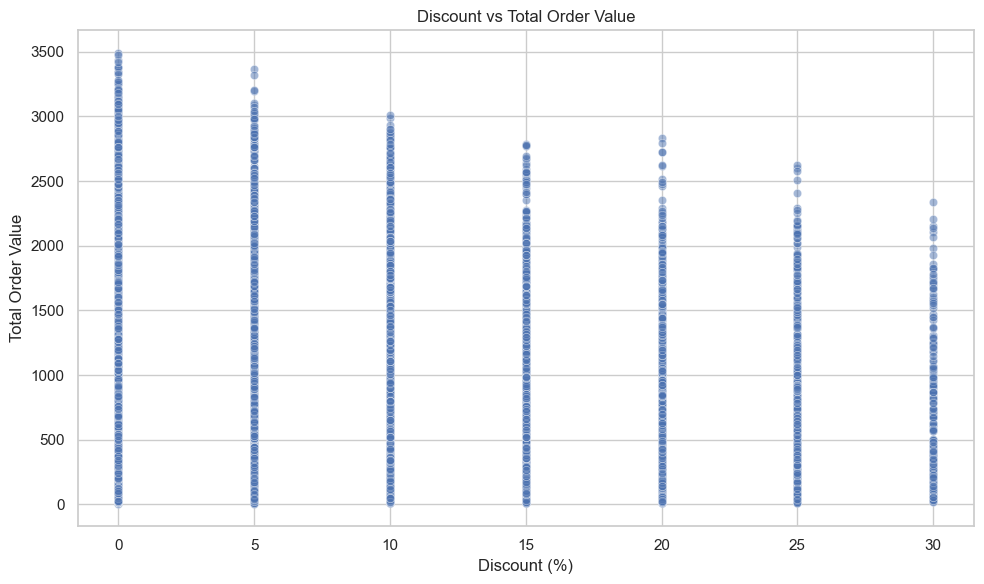

In [20]:
sample_df = df.sample(
    min(10000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="DiscountPercent",
    y="TotalAmount",
    alpha=0.5
)

plt.title("Discount vs Total Order Value")
plt.xlabel("Discount (%)")
plt.ylabel("Total Order Value")

plt.tight_layout()
plt.show()


In [21]:
discount_order_value = (
    df.groupby("DiscountPercent")
      .agg(
          Orders=("OrderID", "nunique"),
          Average_Order_Value=("TotalAmount", "mean"),
          Median_Order_Value=("TotalAmount", "median"),
          NetProductSales=("NetProductSales", "sum")
      )
      .reset_index()
)

discount_order_value


,DiscountPercent,Orders,Average_Order_Value,Median_Order_Value,NetProductSales
0,0.0,40246,987.906980,775.390,3.651437e+07
1,5.0,19889,942.945836,748.080,1.719961e+07
2,10.0,14910,898.122127,701.645,1.226930e+07
3,15.0,10041,841.706168,656.480,7.745153e+06
4,20.0,7939,793.679578,623.810,5.776865e+06
5,25.0,4986,746.731145,579.330,3.409655e+06
6,30.0,1989,726.645395,592.630,1.323143e+06


## 9. Discount Tier Analysis

Discount levels are grouped into business-oriented tiers to make the analysis easier to communicate.

- **No Discount:** 0%
- **Low Discount:** greater than 0% up to 10%
- **Medium Discount:** greater than 10% up to 20%
- **High Discount:** greater than 20%

These tiers are analytical groupings created for this notebook and are not provided as official business policy in the dataset.


In [22]:
def discount_tier(discount):
    if discount == 0:
        return "No Discount"
    elif discount <= 0.10:
        return "Low Discount"
    elif discount <= 0.20:
        return "Medium Discount"
    else:
        return "High Discount"

df["DiscountTier"] = df["Discount"].apply(discount_tier)

discount_tier_summary = (
    df.groupby("DiscountTier")
      .agg(
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum"),
          GrossProductValue=("GrossProductValue", "sum"),
          DiscountAmount=("DiscountAmount", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          Average_Order_Value=("TotalAmount", "mean"),
          Average_Quantity=("Quantity", "mean")
      )
      .reset_index()
)

tier_order = [
    "No Discount",
    "Low Discount",
    "Medium Discount",
    "High Discount"
]

discount_tier_summary["DiscountTier"] = pd.Categorical(
    discount_tier_summary["DiscountTier"],
    categories=tier_order,
    ordered=True
)

discount_tier_summary = (
    discount_tier_summary
    .sort_values("DiscountTier")
)

discount_tier_summary["Weighted_Discount_%"] = (
    discount_tier_summary["DiscountAmount"]
    / discount_tier_summary["GrossProductValue"]
    * 100
)

discount_tier_summary


,DiscountTier,Orders,Units,GrossProductValue,DiscountAmount,NetProductSales,Average_Order_Value,Average_Quantity,Weighted_Discount_%
3,No Discount,40246,120977,36514370.18,0.000000e+00,3.651437e+07,987.906980,3.005938,0.000000
1,Low Discount,34799,104281,31737404.69,2.268498e+06,2.946891e+07,923.740643,2.996667,7.147711
2,Medium Discount,17980,53880,16333026.26,2.811008e+06,1.352202e+07,820.500211,2.996663,17.210577
0,High Discount,6975,21002,6436411.86,1.703613e+06,4.732799e+06,741.003467,3.011039,26.468368


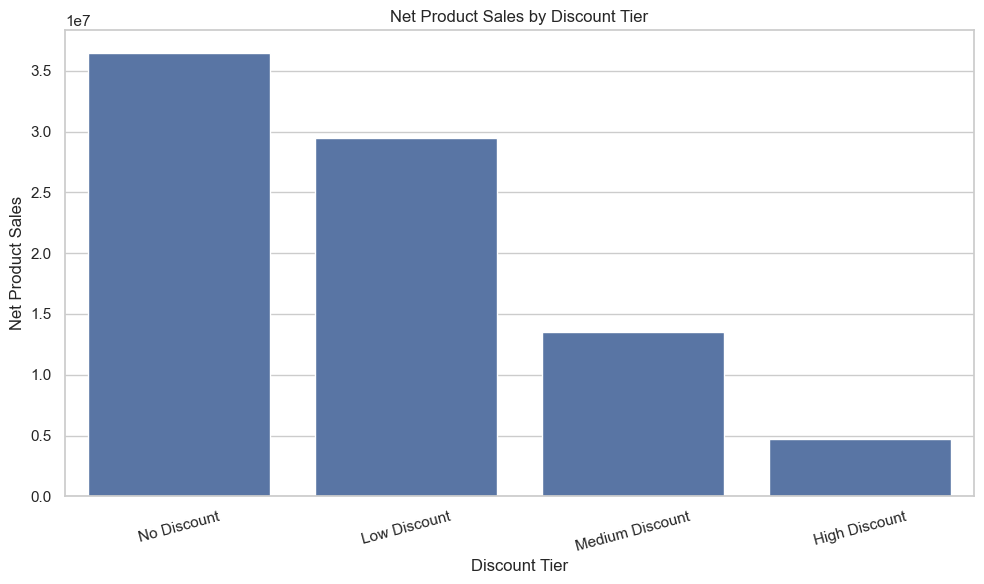

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=discount_tier_summary,
    x="DiscountTier",
    y="NetProductSales"
)

plt.title("Net Product Sales by Discount Tier")
plt.xlabel("Discount Tier")
plt.ylabel("Net Product Sales")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


## 10. High-Discount Product Analysis

Products receiving the highest discounts are identified for review.

High discount does not automatically mean poor performance. The purpose is to identify products that may warrant closer examination of pricing strategy, demand, and sales contribution.


In [24]:
product_discount = (
    df.groupby(
        [
            "ProductID",
            "ProductName",
            "Category",
            "Brand"
        ]
    )
    .agg(
        Orders=("OrderID", "nunique"),
        Units=("Quantity", "sum"),
        Average_Unit_Price=("UnitPrice", "mean"),
        Average_Discount=("Discount", "mean"),
        Weighted_Discount_Amount=("DiscountAmount", "sum"),
        GrossProductValue=("GrossProductValue", "sum"),
        NetProductSales=("NetProductSales", "sum"),
        Average_Effective_Price=("EffectiveUnitPrice", "mean")
    )
    .reset_index()
)

product_discount["Weighted_Discount_%"] = (
    product_discount["Weighted_Discount_Amount"]
    / product_discount["GrossProductValue"]
    * 100
)

top_high_discount_products = (
    product_discount
    .sort_values(
        ["Weighted_Discount_%", "NetProductSales"],
        ascending=[False, False]
    )
    .head(15)
)

top_high_discount_products


,ProductID,ProductName,Category,Brand,Orders,Units,Average_Unit_Price,Average_Discount,Weighted_Discount_Amount,GrossProductValue,NetProductSales,Average_Effective_Price,Weighted_Discount_%
2627,P00044,Power Bank 20000mAh,Sports & Outdoors,ReadMore,31,94,286.973871,0.114516,4060.8985,28018.55,23957.6515,249.206419,14.493607
2009,P00034,Desk Organizer,Electronics,Zenith,26,77,329.370385,0.115385,3493.1925,24140.14,20646.9475,283.835365,14.470473
2948,P00050,Novel Bestseller,Books,UrbanStyle,28,70,277.955000,0.125000,2920.3240,20770.09,17849.7660,243.577143,14.060238
2921,P00049,Children's Book,Sports & Outdoors,BrightLux,31,90,278.798065,0.130645,3386.1065,24314.43,20928.3235,238.777694,13.926325
2746,P00046,Car Charger,Sports & Outdoors,NexPro,29,94,307.545172,0.122414,4224.4970,30762.94,26538.4430,266.063172,13.732423
2876,P00048,Wireless Charger,Toys & Games,NexPro,23,75,316.942609,0.102174,3101.5580,22586.68,19485.1220,276.832957,13.731801
753,P00013,Action Camera,Home & Kitchen,FitLife,27,72,337.981481,0.116667,3286.4685,24222.16,20935.6915,291.422907,13.568024
2749,P00046,Car Charger,Sports & Outdoors,Zenith,22,62,259.090455,0.100000,2222.7015,16434.41,14211.7085,226.184455,13.524681
732,P00013,Action Camera,Clothing,CoreTech,26,76,308.546154,0.105769,3089.5175,23290.77,20201.2525,270.364942,13.264987
2769,P00047,Memory Card 128GB,Books,Zenith,18,49,309.251111,0.130556,1918.0895,14652.28,12734.1905,266.097139,13.090724


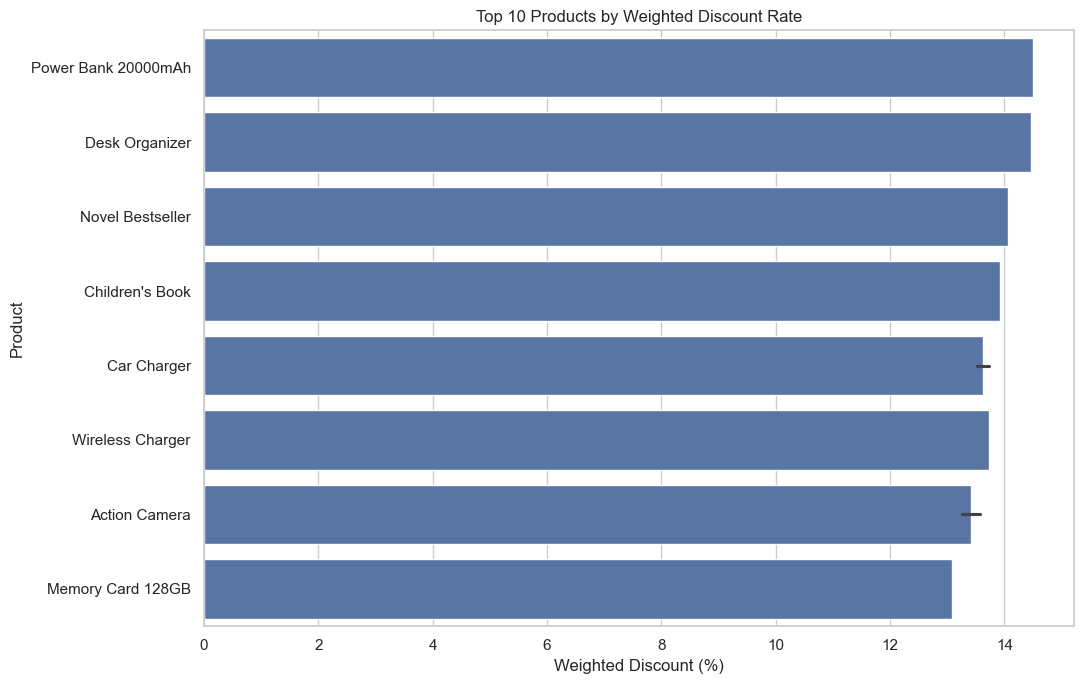

In [25]:
top_discount_products = (
    product_discount
    .sort_values("Weighted_Discount_%", ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_discount_products,
    x="Weighted_Discount_%",
    y="ProductName"
)

plt.title("Top 10 Products by Weighted Discount Rate")
plt.xlabel("Weighted Discount (%)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()


## 11. Category Pricing Analysis

Category-level pricing is compared using list price, effective price, discount, and sales contribution.

The objective is to distinguish categories that generate sales through higher prices from categories that depend more heavily on transaction volume.


In [26]:
category_pricing = (
    df.groupby("Category")
      .agg(
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          Average_Unit_Price=("UnitPrice", "mean"),
          Average_Effective_Price=("EffectiveUnitPrice", "mean"),
          Average_Discount=("Discount", "mean"),
          Total_Discount=("DiscountAmount", "sum")
      )
      .reset_index()
)

category_pricing["Price_Reduction_%"] = (
    (
        category_pricing["Average_Unit_Price"]
        - category_pricing["Average_Effective_Price"]
    )
    / category_pricing["Average_Unit_Price"]
    * 100
)

category_pricing.sort_values(
    "Average_Effective_Price",
    ascending=False
)


,Category,Orders,Units,NetProductSales,Average_Unit_Price,Average_Effective_Price,Average_Discount,Total_Discount,Price_Reduction_%
1,Clothing,16439,49523,1.399885e+07,305.196414,282.381379,0.073970,1.127570e+06,7.475525
2,Electronics,16853,50696,1.428861e+07,302.926827,280.417528,0.074340,1.144068e+06,7.430606
5,Toys & Games,16542,49773,1.397005e+07,302.810143,280.352128,0.074066,1.117829e+06,7.416533
3,Home & Kitchen,16610,49624,1.390217e+07,302.764196,280.024488,0.075084,1.128609e+06,7.510699
0,Books,16752,49981,1.399641e+07,302.023176,279.554902,0.073896,1.132719e+06,7.439255
4,Sports & Outdoors,16804,50543,1.408199e+07,301.757574,279.317202,0.074000,1.132323e+06,7.436556


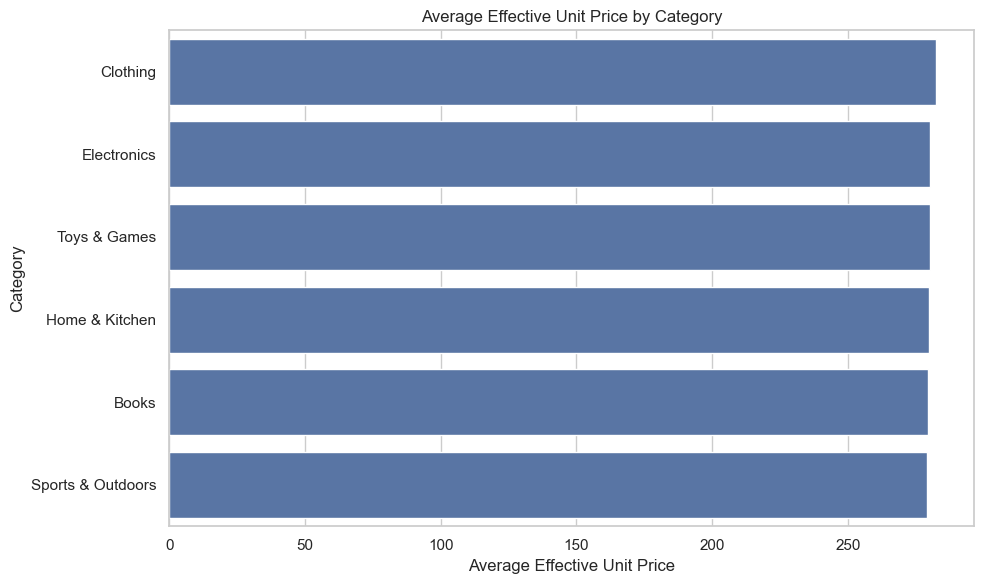

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_pricing.sort_values(
        "Average_Effective_Price",
        ascending=False
    ),
    x="Average_Effective_Price",
    y="Category"
)

plt.title("Average Effective Unit Price by Category")
plt.xlabel("Average Effective Unit Price")
plt.ylabel("Category")

plt.tight_layout()
plt.show()


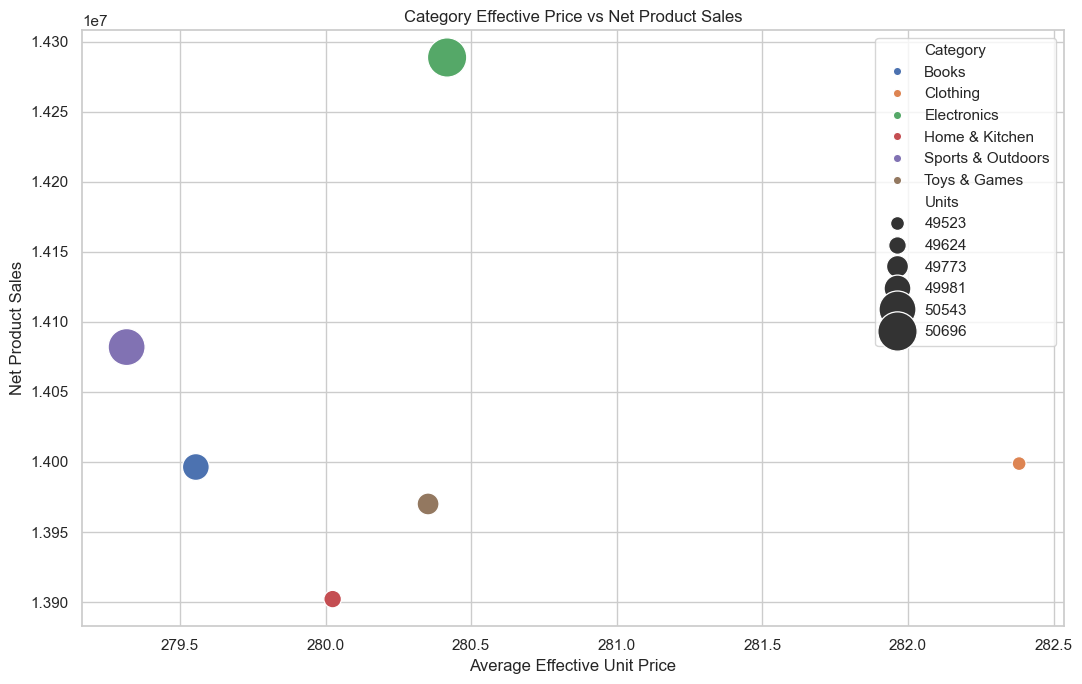

In [28]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=category_pricing,
    x="Average_Effective_Price",
    y="NetProductSales",
    size="Units",
    hue="Category",
    sizes=(100, 800)
)

plt.title("Category Effective Price vs Net Product Sales")
plt.xlabel("Average Effective Unit Price")
plt.ylabel("Net Product Sales")

plt.tight_layout()
plt.show()


## 12. Discount and Pricing Correlation

Correlation is used as a descriptive tool to examine linear relationships among discount, price, quantity, discount amount, and order value.

Correlation does **not** establish causation.


In [29]:
correlation_columns = [
    "Quantity",
    "UnitPrice",
    "Discount",
    "DiscountAmount",
    "EffectiveUnitPrice",
    "NetProductSales",
    "TotalAmount"
]

pricing_correlation = df[correlation_columns].corr()

pricing_correlation


,Quantity,UnitPrice,Discount,DiscountAmount,EffectiveUnitPrice,NetProductSales,TotalAmount
Quantity,1.000000,0.004408,-0.000398,0.292148,0.004309,0.596364,0.594928
UnitPrice,0.004408,1.000000,0.006159,0.354001,0.983937,0.717395,0.715808
Discount,-0.000398,0.006159,1.000000,0.688129,-0.149245,-0.108597,-0.108088
DiscountAmount,0.292148,0.354001,0.688129,1.000000,0.207190,0.357927,0.357574
EffectiveUnitPrice,0.004309,0.983937,-0.149245,0.207190,1.000000,0.728922,0.727224
NetProductSales,0.596364,0.717395,-0.108597,0.357927,0.728922,1.000000,0.997566
TotalAmount,0.594928,0.715808,-0.108088,0.357574,0.727224,0.997566,1.000000


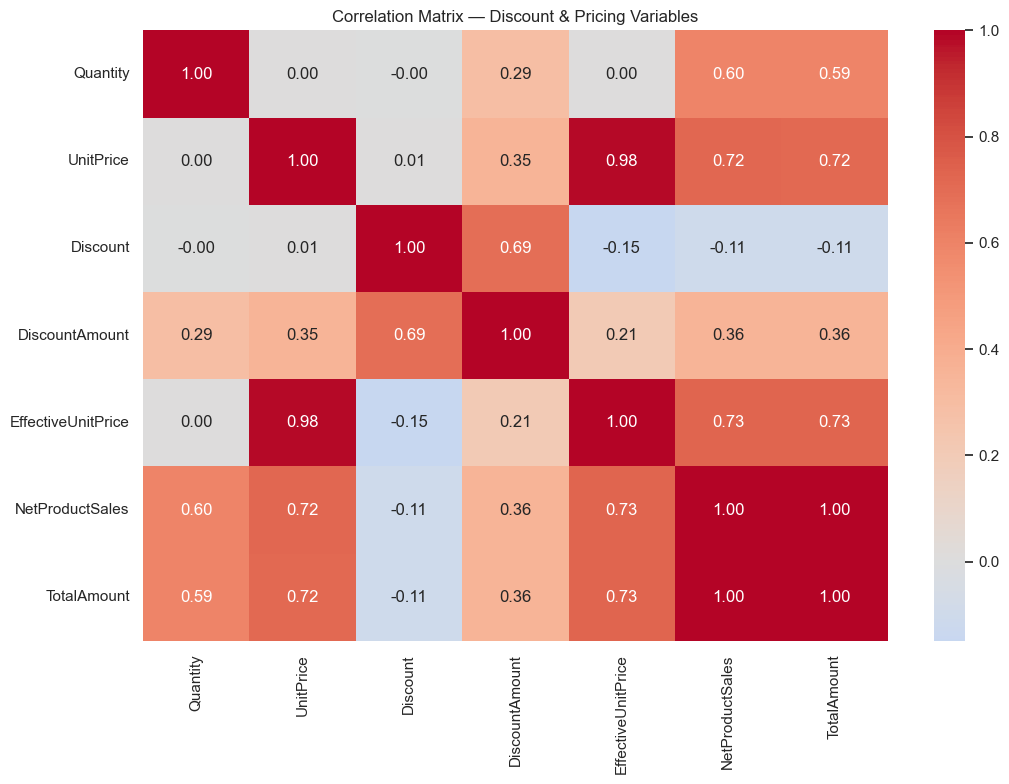

In [30]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    pricing_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix — Discount & Pricing Variables")

plt.tight_layout()
plt.show()


## 13. Discount Contribution to Sales

This section evaluates how much of the total gross product value is represented by discounts and how much remains as net product sales.

This is a sales-value analysis, not a profitability analysis.


In [31]:
discount_impact = pd.DataFrame({
    "Metric": [
        "Gross Product Value",
        "Discount Amount",
        "Net Product Sales"
    ],
    "Value": [
        total_gross_product_value,
        total_discount_amount,
        total_net_product_sales
    ]
})

discount_impact["Share_of_Gross_Product_Value_%"] = (
    discount_impact["Value"]
    / total_gross_product_value
    * 100
)

discount_impact


,Metric,Value,Share_of_Gross_Product_Value_%
0,Gross Product Value,9.102121e+07,100.00000
1,Discount Amount,6.783119e+06,7.45224
2,Net Product Sales,8.423809e+07,92.54776


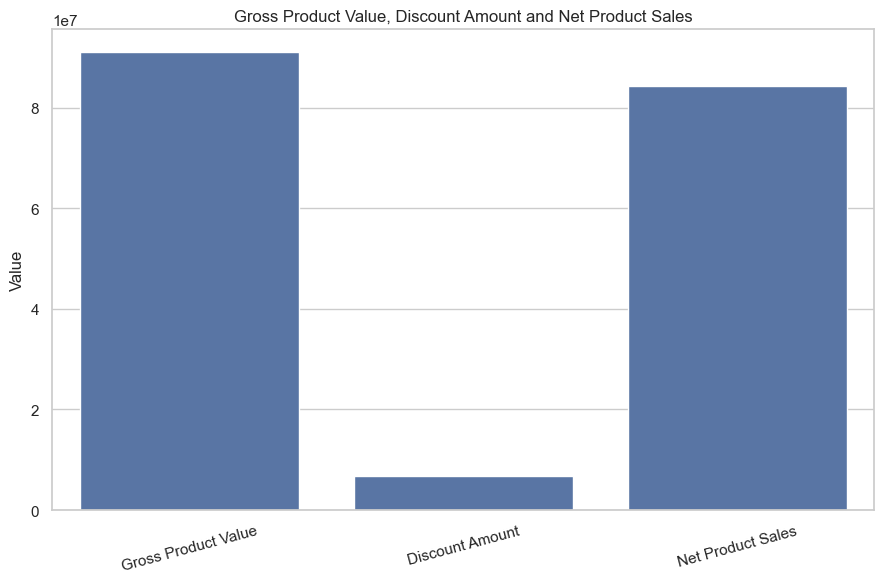

In [32]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=discount_impact,
    x="Metric",
    y="Value"
)

plt.title("Gross Product Value, Discount Amount and Net Product Sales")
plt.xlabel("")
plt.ylabel("Value")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


## 14. Key Business Questions

The following cells produce direct answers to the main discount and pricing questions using the cleaned dataset.


In [33]:
highest_discount_category = (
    category_discount
    .sort_values("Weighted_Discount_%", ascending=False)
    .iloc[0]
)

highest_sales_category = (
    category_discount
    .sort_values("NetProductSales", ascending=False)
    .iloc[0]
)

highest_discount_brand = (
    brand_discount
    .sort_values("Weighted_Discount_%", ascending=False)
    .iloc[0]
)

highest_sales_brand = (
    brand_discount
    .sort_values("NetProductSales", ascending=False)
    .iloc[0]
)

highest_discount_level = (
    discount_distribution
    .sort_values("Orders", ascending=False)
    .iloc[0]
)

highest_sales_discount_level = (
    discount_distribution
    .sort_values("NetProductSales", ascending=False)
    .iloc[0]
)

highest_price_category = (
    category_pricing
    .sort_values("Average_Effective_Price", ascending=False)
    .iloc[0]
)

print(
    f"Weighted discount rate: {weighted_discount_rate:.2f}%"
)

print(
    f"Most frequently used discount: "
    f"{highest_discount_level['DiscountPercent']:.0f}% "
    f"({int(highest_discount_level['Orders']):,} orders)"
)

print(
    f"Discount level with highest net product sales: "
    f"{highest_sales_discount_level['DiscountPercent']:.0f}% "
    f"(${highest_sales_discount_level['NetProductSales']:,.2f})"
)

print(
    f"Highest-discount category: "
    f"{highest_discount_category['Category']} "
    f"({highest_discount_category['Weighted_Discount_%']:.2f}%)"
)

print(
    f"Highest net-sales category: "
    f"{highest_sales_category['Category']} "
    f"(${highest_sales_category['NetProductSales']:,.2f})"
)

print(
    f"Highest-discount brand: "
    f"{highest_discount_brand['Brand']} "
    f"({highest_discount_brand['Weighted_Discount_%']:.2f}%)"
)

print(
    f"Highest net-sales brand: "
    f"{highest_sales_brand['Brand']} "
    f"(${highest_sales_brand['NetProductSales']:,.2f})"
)

print(
    f"Category with highest average effective price: "
    f"{highest_price_category['Category']} "
    f"(${highest_price_category['Average_Effective_Price']:,.2f})"
)


Weighted discount rate: 7.45%
Most frequently used discount: 0% (40,246 orders)
Discount level with highest net product sales: 0% ($36,514,370.18)
Highest-discount category: Home & Kitchen (7.51%)
Highest net-sales category: Electronics ($14,288,614.19)
Highest-discount brand: FitLife (7.65%)
Highest net-sales brand: CoreTech ($8,570,598.84)
Category with highest average effective price: Clothing ($282.38)


## 15. Discount & Pricing Business Insights

The following principles should be used when interpreting the results:

### 1. Discount intensity

The weighted discount rate measures the proportion of gross product value represented by discounts.

### 2. Discount concentration

A small number of discount levels may account for most transactions. These levels represent the core discount structure visible in the dataset.

### 3. Category strategy

Categories with high discounts and high sales volume may indicate strong promotional activity, but the dataset cannot determine whether discounts caused the volume.

### 4. Price positioning

Categories with higher effective prices may generate sales through higher transaction values, while lower-priced categories may depend more on unit volume.

### 5. High-discount products

Products with unusually high discounts should be reviewed alongside their units sold and sales contribution rather than being treated as automatically successful or unsuccessful.

### 6. Profitability limitation

Because product cost is unavailable, discount effectiveness cannot be measured using profit or margin. A discount can increase sales while still reducing profitability.

### 7. Causal limitation

The observed dataset is observational. Correlation between discount and quantity or order value should not be interpreted as proof that discounting caused changes in demand.


## 16. Export Analysis Outputs

Key tables are exported so that they can be reused in the SQL and Power BI stages of the project.


In [34]:
output_dir = Path("../data/discount_pricing_outputs")

if not output_dir.exists():
    output_dir.mkdir(parents=True, exist_ok=True)

discount_overview.to_csv(
    output_dir / "discount_overview.csv",
    index=False
)

discount_distribution.to_csv(
    output_dir / "discount_distribution.csv",
    index=False
)

category_discount.to_csv(
    output_dir / "category_discount_analysis.csv",
    index=False
)

brand_discount.to_csv(
    output_dir / "brand_discount_analysis.csv",
    index=False
)

discount_quantity.to_csv(
    output_dir / "discount_quantity_analysis.csv",
    index=False
)

discount_order_value.to_csv(
    output_dir / "discount_order_value_analysis.csv",
    index=False
)

discount_tier_summary.to_csv(
    output_dir / "discount_tier_analysis.csv",
    index=False
)

product_discount.to_csv(
    output_dir / "product_discount_analysis.csv",
    index=False
)

category_pricing.to_csv(
    output_dir / "category_pricing_analysis.csv",
    index=False
)

pricing_correlation.to_csv(
    output_dir / "pricing_correlation.csv"
)

print("Analysis outputs exported successfully.")
print("Output directory:", output_dir)


Analysis outputs exported successfully.
Output directory: ..\data\discount_pricing_outputs


# 17. Conclusion

This notebook provided a focused analysis of discount and pricing behavior across the e-commerce dataset.

The analysis examined:

- Overall discount intensity
- Gross product value and net product sales
- Total discount amount
- Discount-level distribution
- Effective selling price
- Category-level discount behavior
- Brand-level discount behavior
- Discount versus quantity
- Discount versus order value
- Discount tiers
- High-discount products
- Category pricing
- Pricing and discount correlations

The analysis provides a structured view of how discounts and prices are distributed across the business.

However, **discount effectiveness should not be interpreted as profitability** because the dataset does not contain product cost or margin information.

The results from this notebook will be used in the subsequent **Seller Analysis**, **Geographic Analysis**, **Order & Payment Analysis**, and **Final Business Insights** notebooks.
